## 1. Imports and model setup

This block imports the numerical and plotting libraries used throughout the notebook, then sets the main parameters of the option-pricing problem.

It defines:
- the initial stock price `S0`, strike `K`, barrier level `B`, interest rate `r`, volatility `sigma`, and maturity `T`;
- the Monte Carlo resolution through the number of simulated paths `n_paths` and time steps `n_steps`;
- the time increment `dt`;
- a random number generator with a fixed seed so the simulation is reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Core option & model parameters
S0 = 100.0     # initial stock price
K = 100.0      # strike price
B = 90.0       # barrier level (down-and-out barrier)
r = 0.05       # risk-free rate
sigma = 0.2    # volatility
T = 1.0        # maturity (in years)

n_paths = 100_000   # number of Monte Carlo paths
n_steps = 252       # number of time steps (e.g. trading days)

dt = T / n_steps

rng = np.random.default_rng(seed=42)

## 2. Simulating stock-price paths under geometric Brownian motion

This block generates Monte Carlo sample paths for the stock price under the risk-neutral Black–Scholes model.

The idea is:
- first draw standard normal random variables for every path and every time step;
- use these to build the log-increments of geometric Brownian motion;
- take cumulative sums to obtain the full log-price trajectory;
- exponentiate and multiply by `S0` to recover the stock-price paths;
- finally prepend the initial value `S0` so each path starts at time `t = 0`.

The resulting array `S_paths_full` contains one full simulated stock-price path in each row.


In [2]:
# The GBM dynamics under risk-neutral measure:
#    S_{t+dt} = S_t * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z_t)

# Generate standard normal values for each path and time step
Z = rng.standard_normal((n_paths, n_steps))  # we generating n_paths paths, where each path has n_steps standard normal values.

#Z.shape gives the dimensions of this array : (100000, 252)


# Log-increments for GBM
increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Cumulative sum to get log-price path
log_paths = np.cumsum(increments, axis=1) #for each path (axis=1 ensures this), we summing each time-step incrementally 

# Convert to price paths: S_t = S0 * exp(log_path_t)
S_paths = S0 * np.exp(log_paths)

# Add S0 at the start (time t=0) to get full path including initial point
S_paths_full = np.concatenate(
    [S0 * np.ones((n_paths, 1)), S_paths],
    axis=1
)    #we simply make a column vector with all having S_0, and then glue it to the S_paths array.

# Interpretation:
# S_paths_full has shape (n_paths, n_steps+1).
# Each row i is one simulated path: [S_0, S_dt, S_2dt, ..., S_T].


## 3. Detecting barrier hits and computing option payoffs

This block turns the simulated price paths into option payoffs.

For a **down-and-out call**:
- if a path ever falls to or below the barrier `B`, the option is knocked out and the payoff is set to `0`;
- otherwise the payoff is the usual European call payoff `max(S_T - K, 0)`.

The code therefore:
- finds the minimum value along each simulated path;
- checks which paths breached the barrier;
- computes terminal stock prices `S_T`;
- computes both vanilla-call payoffs and barrier-call payoffs;
- discounts the average payoff to estimate the Monte Carlo prices.

This is the main pricing block of the notebook.


In [3]:
# We are pricing a *down-and-out* call:
# - If the price ever falls to or below B during [0, T], payoff = 0.
# - Otherwise, payoff at maturity = max(S_T - K, 0).


# Check if the barrier is ever breached (down-and-out condition):
# If min price along the path <= B, the option is knocked out.
min_prices = S_paths_full.min(axis=1) #finds the minimum of each path
is_knocked_out = min_prices <= B  #boolean values that gives True/False to each path that has a minimum values smaller than the barrier

# Terminal prices
ST = S_paths_full[:, -1]

# Vanilla call payoff for each path
vanilla_payoff = np.maximum(ST - K, 0.0)

# Barrier call payoff: zero if knocked out, else same as vanilla
barrier_payoff = np.where(is_knocked_out, 0.0, vanilla_payoff) #It gives value 0 if path is knocked out, otherwise the usual vanilla payoff

# Discount back under risk-neutral measure
discount_factor = np.exp(-r * T)
barrier_price_mc = discount_factor * np.mean(barrier_payoff)
vanilla_price_mc = discount_factor * np.mean(vanilla_payoff)

print("Down-and-out call (MC) price:", barrier_price_mc)
print("Vanilla European Call (MC) price:", vanilla_price_mc)

print("Fraction of paths knocked out:", np.mean(is_knocked_out))

# Interpretation:
# - `is_knocked_out[i] = True` means path i hit the barrier at some time. Those paths get payoff 0.
# - Paths that never hit the barrier has payoff max(S_T - K, 0).
# - Averaging discounted payoffs gives the Monte Carlo approximation of the barrier option price under Black–Scholes dynamics.

Down-and-out call (MC) price: 8.963473744812095
Vanilla European Call (MC) price: 10.482858080322604
Fraction of paths knocked out: 0.52411


## 4. Visualising sample paths and highlighting knocked-out trajectories

This block plots a subset of the simulated stock-price paths to show how the barrier feature works visually.

The code:
- selects a manageable number of paths to plot;
- builds the time grid;
- colours knocked-out paths in red and surviving paths in blue;
- adds the barrier level as a dashed horizontal line.

This makes it easy to see which trajectories cross the barrier and therefore contribute zero payoff.


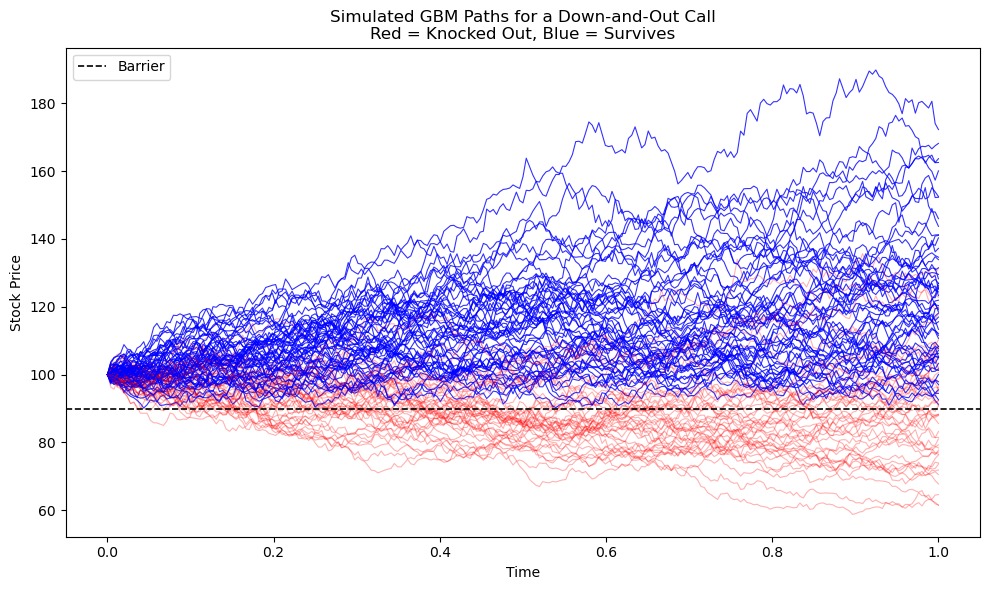

In [4]:
n_plot = 100  # number of sample paths to plot (for clarity)
n_plot = min(n_plot, S_paths_full.shape[0])

time_grid = np.linspace(0, T, S_paths_full.shape[1])

plt.figure(figsize=(10, 6))

for i in range(n_plot):
    # Red if path knocked out, blue otherwise
    color = 'red' if is_knocked_out[i] else 'blue'
    alpha = 0.3 if is_knocked_out[i] else 0.8 #alpha is the transparency of the plots. 0 means completely invisible, 1 is completely solid.
    plt.plot(time_grid, S_paths_full[i], color=color, alpha=alpha, linewidth=0.8)

# Plot the barrier as a dashed line
plt.axhline(B, color='black', linestyle='--', linewidth=1.2, label='Barrier')

plt.title("Simulated GBM Paths for a Down-and-Out Call\nRed = Knocked Out, Blue = Survives")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Interpretation of this plot:
# - Blue paths never go below the barrier → these "survive" and can have non-zero payoff.
# - Red paths touch or go below B at some point → they are knocked out, payoff forced to 0.
# - The barrier line helps visualise how many trajectories are eliminated by the barrier.


## 5. Comparing the payoff distributions

This block compares the payoff distributions of:
- a standard vanilla European call, and
- the down-and-out barrier call.

By plotting both histograms together, we can see that the barrier option has many more zero payoffs because any path that hits the barrier is eliminated. This visual comparison helps explain why the barrier option is cheaper than the corresponding vanilla call.


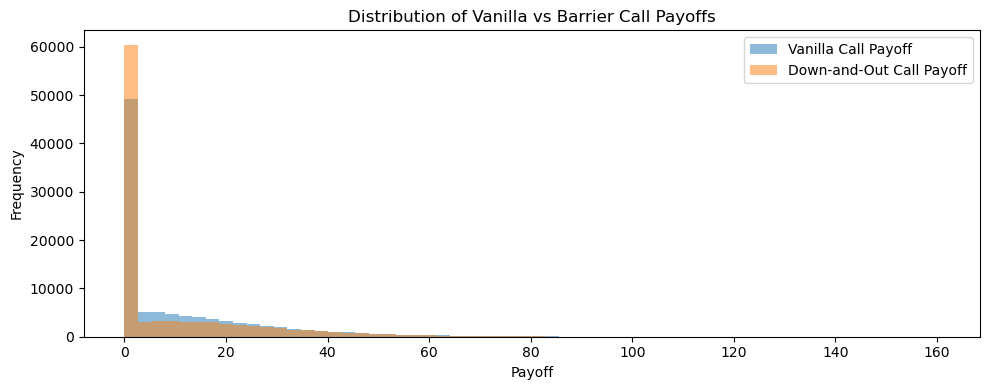

In [5]:
plt.figure(figsize=(10, 4))

# Histogram of vanilla call payoffs
plt.hist(vanilla_payoff, bins=60, alpha=0.5, label='Vanilla Call Payoff')

# Histogram of barrier call payoffs
plt.hist(barrier_payoff, bins=60, alpha=0.5, label='Down-and-Out Call Payoff')

plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.title("Distribution of Vanilla vs Barrier Call Payoffs")
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation:
# - Vanilla payoffs >= barrier payoffs on every path (barrier reduces value).
# - Many barrier payoffs are exactly 0 because paths got knocked out.
# - This visually explains why barrier options are cheaper than vanilla options with the same strike and maturity.


## 6. Benchmarking against the Black–Scholes closed-form price

This final block introduces the Black–Scholes closed-form formula for a vanilla European call and uses it as a benchmark for the Monte Carlo simulation.

The code:
- imports the normal CDF from `scipy.stats`;
- defines a function `bs_call_price(...)` for the analytical Black–Scholes call price;
- computes that analytical value;
- compares it with the Monte Carlo vanilla-call estimate;
- reports the barrier price, pricing error, knockout fraction, and barrier-to-vanilla price ratio.

This serves as a consistency check: if the Monte Carlo simulation is implemented correctly and enough paths are used, the vanilla Monte Carlo price should be close to the Black–Scholes value.


In [6]:
from scipy.stats import norm


# Closed-form Black–Scholes price for vanilla call
def bs_call_price(S0, K, r, sigma, T):
    """Black–Scholes formula for a European call."""
    if T <= 0:
        return max(S0 - K, 0.0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

bs_price = bs_call_price(S0, K, r, sigma, T)

print("============================================")
print("Vanilla European Call (Monte Carlo):", vanilla_price_mc)
print("Down-and-Out Barrier Call (Monte Carlo):", barrier_price_mc)
print("Black–Scholes Vanilla Call (Closed-form):", bs_price)
print("============================================")

print("MC Vanilla vs BS (absolute error):", abs(vanilla_price_mc - bs_price))
print("Barrier / Vanilla price ratio:", barrier_price_mc / vanilla_price_mc)
print("Fraction of paths knocked out:", np.mean(is_knocked_out))

# Interpretation:
# - 'vanilla_price_mc' should be close to 'bs_price' if n_paths is large, validating that the Monte Carlo simulation is correct.
# - 'barrier_price_mc' should be strictly less than the vanilla price, since the barrier feature can only reduce payoff (never increase it).
# - The ratio barrier_price_mc / vanilla_price_mc shows how much cheaper the barrier option is compared to an otherwise identical vanilla call.


Vanilla European Call (Monte Carlo): 10.482858080322604
Down-and-Out Barrier Call (Monte Carlo): 8.963473744812095
Black–Scholes Vanilla Call (Closed-form): 10.450583572185565
MC Vanilla vs BS (absolute error): 0.03227450813703925
Barrier / Vanilla price ratio: 0.8550601063308728
Fraction of paths knocked out: 0.52411
